In [2]:
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langchain_huggingface import ChatHuggingFace , HuggingFaceEndpoint
from langchain_core.messages import BaseMessage, HumanMessage 
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict, Annotated
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()  # Load environment variables from .env file

True

In [4]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
llm = ChatHuggingFace(llm=HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct", 
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"), 
))

e:\AI_Learning\langgraph_learning\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def chat_node(state: ChatState) -> ChatState:
    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)
    
    # response store state
    return {"messages": [response]}

In [7]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

# nodes
graph.add_node('chat_node', chat_node)

# edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

# compile graph
chatbot = graph.compile(checkpointer=checkpointer)

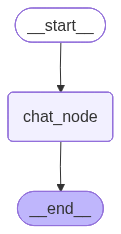

In [8]:
chatbot

In [9]:
thread_id = '1'

while True:

    user_message =input('Type here:')
    print(f'User: {user_message}')

    if user_message.strip().lower() in ['exit', 'quit','bye']:
        print('Goodbye!')
        break

    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({"messages": [HumanMessage(content=user_message)]}, config=config)
    print(f'AI: {response["messages"][-1].content}')

User: Hi


Failed to get info from https://smith.langchain.com: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
Failed to batch ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/batch in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/batch', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


AI: Hello! 😊 How can I help you today?


Failed to batch ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/batch in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/batch', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


User: What is the capital of INDIA?


Failed to batch ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/batch in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/batch', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


AI: The capital of **India** is **New Delhi**.

New Delhi is a part of the larger **National Capital Territory (NCT) of Delhi**, which serves as the political and administrative center of the country. 🇮🇳


Failed to batch ingest runs: langsmith.utils.LangSmithError: Failed to POST https://smith.langchain.com/runs/batch in LangSmith API. HTTPError('405 Client Error: Method Not Allowed for url: https://smith.langchain.com/runs/batch', '<html>\r\n<head><title>405 Not Allowed</title></head>\r\n<body>\r\n<center><h1>405 Not Allowed</h1></center>\r\n<hr><center>nginx</center>\r\n</body>\r\n</html>\r\n')


User: exit
Goodbye!


In [10]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='cd9dcd48-6005-466e-960a-8a4aced8d7d1'), AIMessage(content='Hello! 😊 How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 4, 'total_tokens': 17}, 'model_name': 'meta-llama/Llama-3.1-8B-Instruct', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='run--714d2772-d6b0-4385-bb50-d239247000d7-0', usage_metadata={'input_tokens': 4, 'output_tokens': 13, 'total_tokens': 17}), HumanMessage(content='What is the capital of INDIA?', additional_kwargs={}, response_metadata={}, id='8cef0a95-ad6c-46d1-ba60-5b043ceb5bcd'), AIMessage(content='The capital of **India** is **New Delhi**.\n\nNew Delhi is a part of the larger **National Capital Territory (NCT) of Delhi**, which serves as the political and administrative center of the country. 🇮🇳', additional_kwargs={}, response_metadata={'token_usage': 